In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import pandas as pd
from collections import defaultdict, deque
import matplotlib.patches as patches
from scipy.spatial import Delaunay
from astropy.table import vstack
from collections import defaultdict

In [2]:
raw_data = Table.read('../../ASTRA-DESI-EDR/raw/zone_01.fits.gz')
class_data = Table.read('../../ASTRA-DESI-EDR/classification/zone_01_classified.fits.gz')
pairs_data = Table.read('../../ASTRA-DESI-EDR/pairs/zone_01_pairs.fits.gz')

In [3]:
ii_rand_raw = (raw_data['RANDITER']==0) & (raw_data['TRACERTYPE']=='BGS_ANY_RAND')
ii_data_raw = (raw_data['RANDITER']==-1) & (raw_data['TRACERTYPE']=='BGS_ANY_DATA')

ii_rand_class = (class_data['RANDITER']==0) & (class_data['TRACERTYPE']=='BGS_ANY') & (class_data['ISDATA']==False)
ii_data_class = (class_data['RANDITER']==0) & (class_data['TRACERTYPE']=='BGS_ANY') & (class_data['ISDATA']==True)

ii_pairs = pairs_data['RANDITER']==0

In [4]:
print(np.count_nonzero(ii_rand_raw))
print(np.count_nonzero(ii_data_raw))
print(np.count_nonzero(ii_rand_class))
print(np.count_nonzero(ii_data_class))

13696
13696
13696
13696


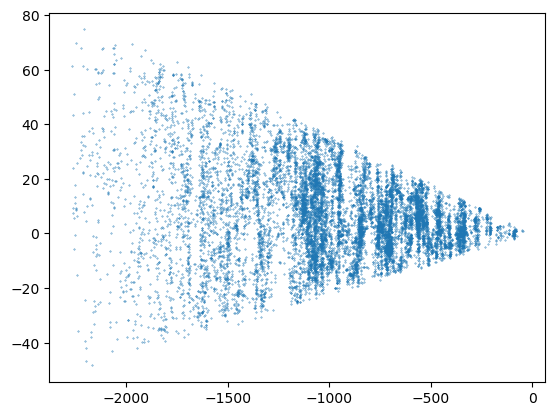

In [5]:
plt.scatter(raw_data['XCART'][ii_data_raw], raw_data['YCART'][ii_data_raw], s=0.1)

In [6]:
raw_table = raw_data[ii_rand_raw][['TARGETID', 'XCART', 'YCART', 'ZCART']]
data_table = raw_data[ii_data_raw][['TARGETID', 'XCART', 'YCART', 'ZCART']]
rand_table = raw_data[ii_rand_raw][['TARGETID', 'XCART', 'YCART', 'ZCART']]
class_table = class_data[ii_rand_class][['TARGETID', 'NDATA', 'NRAND']]
pairs_table = pairs_data[ii_pairs][['TARGETID1','TARGETID2']]
r_values = (class_table['NDATA']-class_table['NRAND'])/(class_table['NDATA']+class_table['NRAND'])
class_table['R'] = r_values

In [7]:
# Concatenate the two astropy tables
combined_table = vstack([data_table, rand_table])

# Extract coordinates for Delaunay triangulation
points = np.column_stack([combined_table['XCART'], 
                          combined_table['YCART'], 
                          combined_table['ZCART']])

# Compute Delaunay triangulation
tri = Delaunay(points)

# Extract all unique pairs from the simplices (tetrahedra in 3D)
pairs_set = set()
for simplex in tri.simplices:
    # Each simplex has 4 vertices, giving 6 edges
    for i in range(4):
        for j in range(i+1, 4):
            # Store pairs in sorted order to avoid duplicates
            pair = tuple(sorted([simplex[i], simplex[j]]))
            pairs_set.add(pair)

# Convert to list and create DataFrame
pairs_list = list(pairs_set)
pairs_indices = np.array(pairs_list)

# Map indices back to TARGETIDs
pairs_table_scratch = pd.DataFrame({
    'TARGETID1': combined_table['TARGETID'][pairs_indices[:, 0]],
    'TARGETID2': combined_table['TARGETID'][pairs_indices[:, 1]]
})

print(f"Number of unique pairs: {len(pairs_table_scratch)}")

Number of unique pairs: 207946


In [8]:
def compute_nrand_ndata(pairs_table, data_targetids, rand_targetids=None):
    """
    Compute NRAND and NDATA for each point based on pairs table.
    
    NDATA: Number of connections to data points
    NRAND: Number of connections to random points
    
    Parameters:
    -----------
    pairs_table : pd.DataFrame
        Table with columns TARGETID1, TARGETID2
    data_targetids : array-like
        Set or array of TARGETIDs that are data points
    rand_targetids : array-like, optional
        Set or array of TARGETIDs that are random points
        If not provided, assumes all points not in data_targetids are random
    
    Returns:
    --------
    pd.DataFrame : Table with columns TARGETID, NDATA, NRAND
    """
    # Convert to sets for fast lookup
    data_set = set(data_targetids)
    
    if rand_targetids is not None:
        rand_set = set(rand_targetids)
    else:
        # All TARGETIDs in pairs that are not in data are assumed random
        all_ids = set(pairs_table['TARGETID1'].unique()) | set(pairs_table['TARGETID2'].unique())
        rand_set = all_ids - data_set
    
    # Initialize counters
    ndata_count = defaultdict(int)
    nrand_count = defaultdict(int)
    
    # Process each pair
    for _, row in pairs_table.iterrows():
        id1 = row['TARGETID1']
        id2 = row['TARGETID2']
        
        # Determine if each ID is data or random
        id1_is_data = id1 in data_set
        id2_is_data = id2 in data_set
        
        # Update counts for id1
        if id2_is_data:
            ndata_count[id1] += 1
        else:
            nrand_count[id1] += 1
        
        # Update counts for id2
        if id1_is_data:
            ndata_count[id2] += 1
        else:
            nrand_count[id2] += 1
    
    # Get all unique TARGETIDs
    all_targets = sorted(set(ndata_count.keys()) | set(nrand_count.keys()))
    
    # Create result table
    result = pd.DataFrame({
        'TARGETID': all_targets,
        'NDATA': [ndata_count[tid] for tid in all_targets],
        'NRAND': [nrand_count[tid] for tid in all_targets]
    })
    
    return result

In [9]:
ndatarandom_df = compute_nrand_ndata(pairs_table_scratch, data_table['TARGETID'], rand_targetids=rand_table['TARGETID'])


In [10]:
ndatarandom_df.sort_values('TARGETID', inplace=True)
class_df = class_table.to_pandas()
class_df.sort_values('TARGETID', inplace=True)

In [11]:
ii_random = np.in1d(ndatarandom_df['TARGETID'], class_df['TARGETID'])

In [12]:
ndatarandom_df = ndatarandom_df[ii_random] 

In [13]:
r_values = (ndatarandom_df['NDATA']-ndatarandom_df['NRAND'])/(ndatarandom_df['NDATA']+ndatarandom_df['NRAND'])

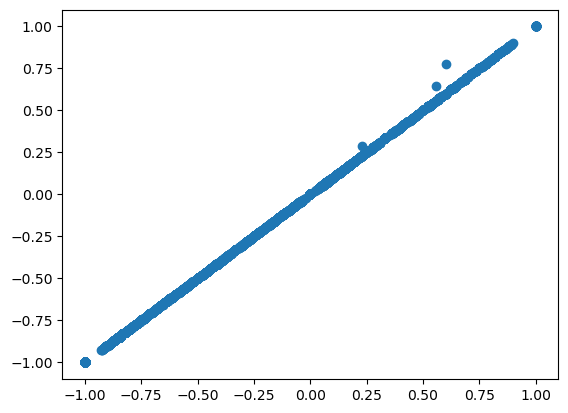

In [14]:
plt.scatter(r_values, class_df['R'])

In [15]:
raw_table

TARGETID,XCART,YCART,ZCART
int64,float64,float64,float64
327858194082695778,-359.6531061661578,5.833492239796129,7.715208158408576
327858139711931270,-914.6810759957439,25.315374658068595,-14.416294984682304
327858188042898140,-975.5016721678589,12.988881861292214,15.496480730350445
327858145781090131,-1996.8445005599272,-5.824494219806081,-28.0853420602118
327858194099473307,-1324.9106487397037,-1.1268049865834555,29.09600209671435
327858200126685574,-1398.8140124247234,15.227828241689117,37.74479984478525
327858163913067150,-1143.5928677756865,-19.855396131117267,0.19509124139644948
327858181998903704,-1522.8463262460277,28.411207797674972,18.3920028212779
327858157860683858,-461.31553136806355,-1.8237783543723654,-1.6119880327757956


In [16]:
class_table

TARGETID,NDATA,NRAND,R
int64,int32,int32,float64
327858194082695778,2,16,-0.7777777777777778
327858139711931270,0,11,-1.0
327858188042898140,6,7,-0.07692307692307693
327858145781090131,7,9,-0.125
327858194099473307,2,12,-0.7142857142857143
327858200126685574,5,8,-0.23076923076923078
327858163913067150,4,7,-0.2727272727272727
327858181998903704,3,11,-0.5714285714285714
327858157860683858,10,11,-0.047619047619047616


In [17]:
pairs_table

TARGETID1,TARGETID2
int64,int64
39627817918402180,327858188030314097
39627817918402180,39627811882796121
39627817918402180,39627817922593467
39627817918402180,39627805838803862
39627817918402180,39627811882796077
39627817918402180,327858188026119468
39627817918402180,327858194074305487
39627817918402180,39627811878600887
39627817918402180,39627817922593828


In [18]:
class WatershedGrouping:
    """
    Watershed algorithm to find groups on a graph based on connectivity and R values.
    
    The algorithm works by:
    1. Starting from points with lowest R values
    2. Assigning points to groups based on connectivity via pairs_table
    3. Only considering points with R <= threshold (default -0.9)
    """
    
    def __init__(self, raw_table, class_table, pairs_table, r_threshold=-0.9):
        """
        Initialize the watershed grouping algorithm.
        
        Parameters:
        -----------
        raw_table : pd.DataFrame
            Table with columns: TARGETID, XCART, YCART, ZCART
        class_table : pd.DataFrame
            Table with columns: TARGETID, NDATA, NRAND, R
        pairs_table : pd.DataFrame
            Table with columns: TARGETID1, TARGETID2 (linked points)
        r_threshold : float
            Maximum R value to consider (default: -0.9)
        """
        self.raw_table = raw_table.copy()
        self.class_table = class_table.copy()
        self.pairs_table = pairs_table.copy()
        self.r_threshold = r_threshold
        
        # Initialize GROUPID column
        self.raw_table['GROUPID'] = -1
        
        # Build adjacency graph from pairs_table
        self.graph = self._build_graph()
        
        # Filter class_table by R threshold and sort by R
        self.filtered_class = self.class_table[
            self.class_table['R'] <= self.r_threshold
        ].sort_values('R').reset_index(drop=True)
        
    def _build_graph(self):
        """Build adjacency list from pairs_table."""
        graph = defaultdict(set)
        
        for _, row in self.pairs_table.iterrows():
            id1 = row['TARGETID1']
            id2 = row['TARGETID2']
            graph[id1].add(id2)
            graph[id2].add(id1)
        
        return graph
    
    def _get_neighbors(self, target_id):
        """Get all neighbors of a given target_id from the graph."""
        return self.graph.get(target_id, set())
    
    def _is_connected_to_group(self, target_id, group_id):
        """Check if a point is connected to any point in the given group."""
        neighbors = self._get_neighbors(target_id)
        
        # Get all points in the specified group
        group_points = set(
            self.raw_table[self.raw_table['GROUPID'] == group_id]['TARGETID'].values
        )
        
        # Check if any neighbor is in the group
        return len(neighbors & group_points) > 0
    
    def _assign_to_existing_or_new_group(self, target_id, current_max_group):
        """
        Assign a point to an existing group if connected, or create a new group.
        
        Returns:
        --------
        int : The new maximum group ID
        """
        # Check connection to existing groups (from 0 to current_max_group)
        for group_id in range(current_max_group + 1):
            if self._is_connected_to_group(target_id, group_id):
                self.raw_table.loc[
                    self.raw_table['TARGETID'] == target_id, 'GROUPID'
                ] = group_id
                return current_max_group
        
        # Not connected to any existing group, create new group
        new_group_id = current_max_group + 1
        self.raw_table.loc[
            self.raw_table['TARGETID'] == target_id, 'GROUPID'
        ] = new_group_id
        return new_group_id
    
    def run(self, verbose=False):
        """
        Run the watershed grouping algorithm.
        
        Parameters:
        -----------
        verbose : bool
            If True, print progress information
        
        Returns:
        --------
        pd.DataFrame : raw_table with GROUPID column added
        """
        if len(self.filtered_class) == 0:
            if verbose:
                print("No points with R <= threshold found.")
            return self.raw_table
        
        current_max_group = -1
        processed_ids = set()
        
        # Group points by R value to handle ties
        r_groups = self.filtered_class.groupby('R')['TARGETID'].apply(list).to_dict()
        sorted_r_values = sorted(r_groups.keys())
        
        if verbose:
            print(f"Processing {len(self.filtered_class)} points with R <= {self.r_threshold}")
        
        for r_value in sorted_r_values:
            # Get all points with this R value
            candidates = r_groups[r_value]
            
            # Shuffle to handle random selection for ties
            np.random.shuffle(candidates)
            
            for target_id in candidates:
                if target_id in processed_ids:
                    continue
                
                if current_max_group == -1:
                    # First point, initialize first group
                    self.raw_table.loc[
                        self.raw_table['TARGETID'] == target_id, 'GROUPID'
                    ] = 0
                    current_max_group = 0
                    if verbose:
                        print(f"Initialized group 0 with point {target_id} (R={r_value:.4f})")
                else:
                    # Assign to existing group or create new group
                    old_max = current_max_group
                    current_max_group = self._assign_to_existing_or_new_group(
                        target_id, current_max_group
                    )
                    
                    if verbose and current_max_group > old_max:
                        assigned_group = self.raw_table[
                            self.raw_table['TARGETID'] == target_id
                        ]['GROUPID'].values[0]
                        print(f"Created new group {assigned_group} with point {target_id} (R={r_value:.4f})")
                
                processed_ids.add(target_id)
        
        if verbose:
            n_groups = len(self.raw_table[self.raw_table['GROUPID'] >= 0]['GROUPID'].unique())
            n_ungrouped = len(self.raw_table[self.raw_table['GROUPID'] == -1])
            print(f"\nGrouping complete:")
            print(f"  Total groups created: {n_groups}")
            print(f"  Points assigned to groups: {len(processed_ids)}")
            print(f"  Points not assigned (GROUPID=-1): {n_ungrouped}")
        
        return self.raw_table

In [51]:
raw_df = raw_table.to_pandas()
class_df = class_table.to_pandas()
#pairs_df = pairs_table.to_pandas()
pairs_df = pairs_table_scratch.copy()
    
# Run watershed algorithm
watershed = WatershedGrouping(raw_df, class_df, pairs_df, r_threshold=-0.7)
result = watershed.run(verbose=True)
    
print("\nResult:")
print(result)

Processing 3323 points with R <= -0.7
Initialized group 0 with point 327858194078501217 (R=-1.0000)
Created new group 1 with point 327858133693104634 (R=-1.0000)
Created new group 2 with point 327858169915114690 (R=-1.0000)
Created new group 3 with point 327858194086888906 (R=-1.0000)
Created new group 4 with point 327858163875317500 (R=-1.0000)
Created new group 5 with point 327858133705688508 (R=-1.0000)
Created new group 6 with point 327858139728707591 (R=-1.0000)
Created new group 7 with point 327858139720321224 (R=-1.0000)
Created new group 8 with point 327858188055478340 (R=-1.0000)
Created new group 9 with point 327858157860683927 (R=-1.0000)
Created new group 10 with point 327858169906724913 (R=-1.0000)
Created new group 11 with point 327858200122491582 (R=-1.0000)
Created new group 12 with point 327858145751731002 (R=-1.0000)
Created new group 13 with point 327858151837663245 (R=-1.0000)
Created new group 14 with point 327858188072258051 (R=-1.0000)
Created new group 15 with p

In [52]:

def compute_group_statistics(result_table, min_group_size=4):
    """
    Compute center of mass and effective radius for each group.
    
    The center of mass is the mean position of all points in the group.
    The effective radius is the RMS (root mean square) distance of points 
    from the center of mass.
    
    Parameters:
    -----------
    result_table : pd.DataFrame
        Output from watershed algorithm with columns:
        TARGETID, XCART, YCART, ZCART, GROUPID
    min_group_size : int
        Minimum number of points required to compute statistics (default: 1)
    
    Returns:
    --------
    pd.DataFrame : Table with columns:
        - GROUPID: Group identifier
        - N_MEMBERS: Number of points in the group
        - XCART_CM: X coordinate of center of mass
        - YCART_CM: Y coordinate of center of mass
        - ZCART_CM: Z coordinate of center of mass
        - R_EFF: Effective radius (RMS distance from center of mass)
    """
    # Filter out ungrouped points (GROUPID = -1)
    grouped_data = result_table[result_table['GROUPID'] >= 0].copy()
    
    if len(grouped_data) == 0:
        print("Warning: No grouped points found!")
        return pd.DataFrame(columns=['GROUPID', 'N_MEMBERS', 'XCART_CM', 
                                     'YCART_CM', 'ZCART_CM', 'R_EFF'])
    
    # Group by GROUPID and compute statistics
    stats_list = []
    
    for group_id in sorted(grouped_data['GROUPID'].unique()):
        group_points = grouped_data[grouped_data['GROUPID'] == group_id]
        n_members = len(group_points)
        
        # Skip if group is too small
        if n_members < min_group_size:
            continue
        
        # Compute center of mass (mean position)
        xcm = group_points['XCART'].mean()
        ycm = group_points['YCART'].mean()
        zcm = group_points['ZCART'].mean()
        
        # Compute effective radius (RMS distance from center of mass)
        dx = group_points['XCART'] - xcm
        dy = group_points['YCART'] - ycm
        dz = group_points['ZCART'] - zcm
        
        r_squared = dx**2 + dy**2 + dz**2
        r_eff = np.sqrt(r_squared.mean())
        
        stats_list.append({
            'GROUPID': group_id,
            'N_MEMBERS': n_members,
            'XCART_CM': xcm,
            'YCART_CM': ycm,
            'ZCART_CM': zcm,
            'R_EFF': r_eff
        })
    
    stats_df = pd.DataFrame(stats_list)
    
    return stats_df


def compute_group_statistics_extended(result_table, class_table=None, min_group_size=4):
    """
    Compute extended statistics for each group including R value statistics.
    
    Parameters:
    -----------
    result_table : pd.DataFrame
        Output from watershed algorithm with GROUPID column
    class_table : pd.DataFrame, optional
        Table with R values for additional statistics
    min_group_size : int
        Minimum number of points required (default: 1)
    
    Returns:
    --------
    pd.DataFrame : Extended statistics table
    """
    # Get basic statistics
    stats_df = compute_group_statistics(result_table, min_group_size)
    
    if class_table is not None:
        # Merge with class_table to get R values
        grouped_data = result_table[result_table['GROUPID'] >= 0].copy()
        merged = grouped_data.merge(class_table[['TARGETID', 'R']], on='TARGETID', how='left')
        
        # Compute R statistics for each group
        r_stats_list = []
        
        for group_id in sorted(merged['GROUPID'].unique()):
            group_r = merged[merged['GROUPID'] == group_id]['R']
            
            if len(group_r) >= min_group_size:
                r_stats_list.append({
                    'GROUPID': group_id,
                    'R_MIN': group_r.min(),
                    'R_MAX': group_r.max(),
                    'R_MEAN': group_r.mean(),
                    'R_MEDIAN': group_r.median(),
                    'R_STD': group_r.std()
                })
        
        r_stats_df = pd.DataFrame(r_stats_list)
        
        # Merge with basic statistics
        stats_df = stats_df.merge(r_stats_df, on='GROUPID', how='left')
    
    return stats_df



def print_group_summary(stats_df):
    """
    Print a formatted summary of group statistics.
    
    Parameters:
    -----------
    stats_df : pd.DataFrame
        Output from compute_group_statistics
    """
    print("=" * 80)
    print("GROUP STATISTICS SUMMARY")
    print("=" * 80)
    print(f"\nTotal number of groups: {len(stats_df)}")
    
    if len(stats_df) > 0:
        print(f"\nGroup size statistics:")
        print(f"  Total members across all groups: {stats_df['N_MEMBERS'].sum()}")
        print(f"  Min group size: {stats_df['N_MEMBERS'].min()}")
        print(f"  Max group size: {stats_df['N_MEMBERS'].max()}")
        print(f"  Mean group size: {stats_df['N_MEMBERS'].mean():.2f}")
        print(f"  Median group size: {stats_df['N_MEMBERS'].median():.2f}")
        
        print(f"\nEffective radius statistics:")
        print(f"  Min R_EFF: {stats_df['R_EFF'].min():.4f}")
        print(f"  Max R_EFF: {stats_df['R_EFF'].max():.4f}")
        print(f"  Mean R_EFF: {stats_df['R_EFF'].mean():.4f}")
        print(f"  Median R_EFF: {stats_df['R_EFF'].median():.4f}")
        
        print(f"\n{'Top 10 largest groups:':}")
        print("-" * 80)
        top_groups = stats_df.nlargest(10, 'N_MEMBERS')
        print(top_groups[['GROUPID', 'N_MEMBERS', 'R_EFF']].to_string(index=False))
        
        if 'R_MEAN' in stats_df.columns:
            print(f"\nR value statistics:")
            print(f"  Min R_MEAN: {stats_df['R_MEAN'].min():.6f}")
            print(f"  Max R_MEAN: {stats_df['R_MEAN'].max():.6f}")
    
    print("\n" + "=" * 80)


# Compute statistics
stats = compute_group_statistics_extended(result, class_df, min_group_size=4)

# View results
print(stats)


     GROUPID  N_MEMBERS     XCART_CM   YCART_CM   ZCART_CM      R_EFF  \
0          0         96  -500.107404   5.925319   3.615493  14.989851   
1          1         45  -670.825116   3.910348 -10.867560  12.003568   
2          2         42 -1337.069983  35.383757   6.575382  15.574284   
3          4        131  -781.915874  13.045671   2.836095  18.455987   
4          5         16  -681.853452  -3.806432 -14.379899  10.586264   
..       ...        ...          ...        ...        ...        ...   
131      278          5  -297.402688   5.541791  -2.055867   5.627670   
132      290          5 -1981.538953  45.764917  -8.099505  20.401027   
133      302          4  -888.559153  -6.111255 -18.349586   2.911756   
134      328          5 -1736.436646 -28.379769 -17.608796  11.963121   
135      338          4  -781.308364   0.123808 -13.025369   3.522746   

        R_MIN     R_MAX    R_MEAN  R_MEDIAN     R_STD  
0   -1.000000 -0.700000 -0.889446 -0.882353  0.106127  
1   -1.0000

(-1400.0, -1300.0)

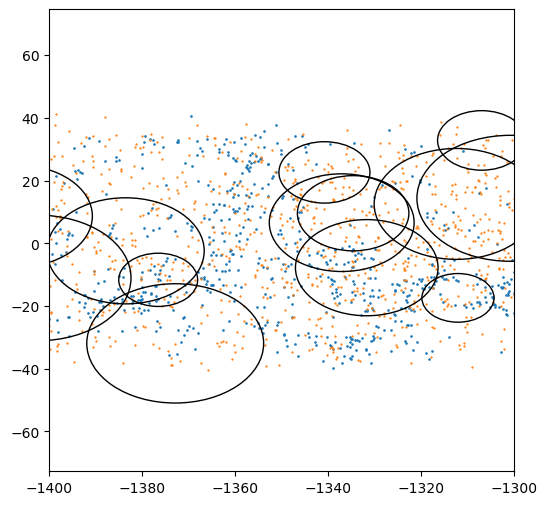

In [55]:
#plt.scatter(result['XCART'][ii], result['YCART'][ii])
fig, ax = plt.subplots(figsize=(6,6))

plt.scatter(data_table['XCART'], data_table['ZCART'], s=0.8)
plt.scatter(rand_table['XCART'], rand_table['ZCART'], s=0.4)


for idx, row in stats.iterrows():
    group_id = row['GROUPID']
    if row['R_EFF']>0.0:
        circle = patches.Circle((row['XCART_CM'], row['ZCART_CM']), row['R_EFF'], fill=False)
        ax.add_patch(circle)

plt.xlim((-1400,-1300))
#plt.ylim()

(array([ 1.,  7., 16., 25., 26., 32., 23.,  3.,  1.,  2.]),
 array([0.23499669, 0.38894366, 0.54289063, 0.69683761, 0.85078458,
        1.00473155, 1.15867853, 1.3126255 , 1.46657247, 1.62051945,
        1.77446642]),
 <BarContainer object of 10 artists>)

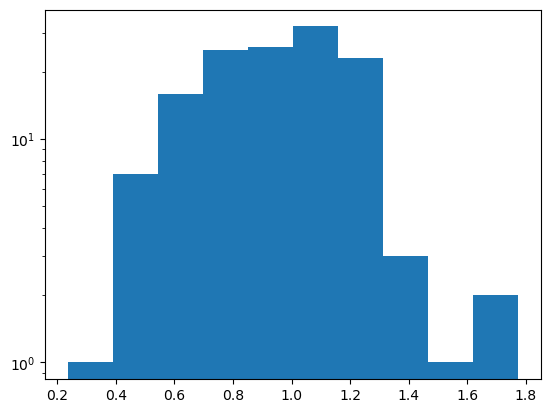

In [56]:
plt.hist(np.log10(stats['R_EFF'][stats['R_EFF']>0]), log=True)

(array([36., 29.,  9., 13., 20., 11.,  7.,  2.,  5.,  4.]),
 array([0.60205999, 0.76438492, 0.92670985, 1.08903478, 1.25135971,
        1.41368464, 1.57600957, 1.73833449, 1.90065942, 2.06298435,
        2.22530928]),
 <BarContainer object of 10 artists>)

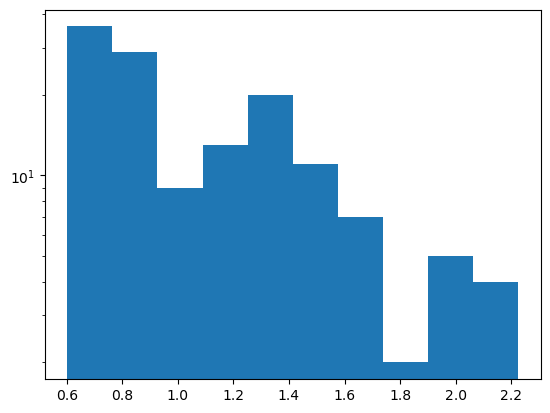

In [57]:
plt.hist(np.log10(stats['N_MEMBERS']), log=True)

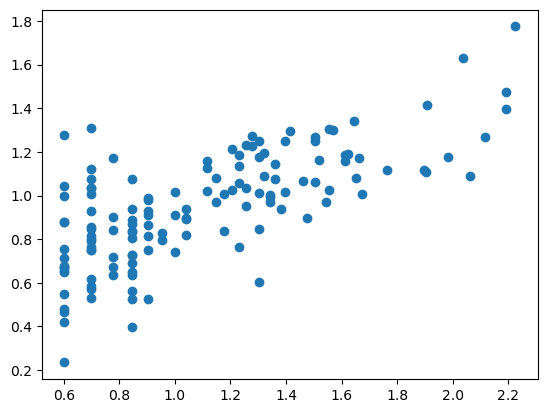

In [58]:
plt.scatter(np.log10(stats['N_MEMBERS']), np.log10(stats['R_EFF']))

16


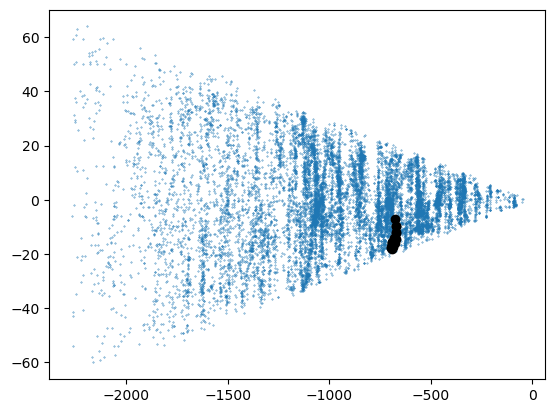

In [59]:
ll = result['GROUPID']==5
print(np.count_nonzero(ll))
plt.scatter(data_table['XCART'], data_table['ZCART'], s=0.1)
#plt.scatter(stats['XCART_CM'], stats['YCART_CM'])
plt.scatter(result['XCART'][ll], result['ZCART'][ll], color='black')
#plt.xlim((-200,-10))


In [26]:
result

,TARGETID,XCART,YCART,ZCART,GROUPID
0,327858194082695778,-359.653106,5.833492,7.715208,-1
1,327858139711931270,-914.681076,25.315375,-14.416295,11
2,327858188042898140,-975.501672,12.988882,15.496481,-1
3,327858145781090131,-1996.844501,-5.824494,-28.085342,-1
4,327858194099473307,-1324.910649,-1.126805,29.096002,-1
...,...,...,...,...,...
13691,327858151804109193,-1240.868808,20.000089,-11.807295,-1
13692,327858145793672060,-444.283295,-7.173080,-5.340309,-1
13693,327858163892093631,-1451.594612,8.566434,0.179255,-1
13694,327858169948670429,-1105.708837,-10.411211,6.073866,-1


(-1000.0, -900.0)

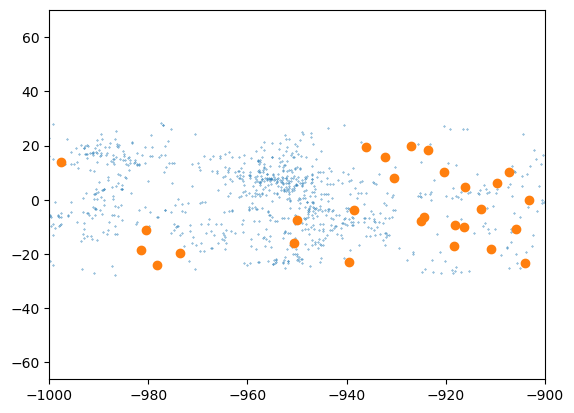

In [27]:
plt.scatter(data_table['XCART'], data_table['ZCART'], s=0.1)
plt.scatter(stats['XCART_CM'], stats['ZCART_CM'])
plt.xlim((-1000,-900))